In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [94]:
# Cargamos los datasets necesarios
patients = pd.read_csv('dataset_p1/2mimic/PATIENTS.csv')
admissions = pd.read_csv('dataset_p1/2mimic/ADMISSIONS.csv')
icustays = pd.read_csv('dataset_p1/2mimic/ICUSTAYS.csv')

| Variable     | Archivo    | Motivo                     |
| ------------ | ---------- | -------------------------- |
| `SUBJECT_ID` | todos      | clave primaria             |
| `HADM_ID`    | admissions | identifica hospitalización |
| `ICUSTAY_ID` | icu        | estancia UCI               |
| `GENDER`     | patients   | factor demográfico         |
| `DOB`        | patients   | calcular edad              |
| `ADMITTIME`  | admissions | contexto                   |
| `DISCHTIME`  | admissions | duración                   |
| `DEATHTIME`  | admissions | etiqueta objetivo          |
| `LOS`        | icu        | duración en UCI            |


In [95]:
# integracion de datos
df = admissions.merge(patients, on='subject_id')
df = df.merge(icustays, on=['subject_id', 'hadm_id'])

# el dataset es pequeño de por si, por que solo pocos hicieron, o participaron en las 3 tablas
print(df.shape)

(136, 36)


In [96]:
df['dob'] = pd.to_datetime(df['dob'])
df['admittime'] = pd.to_datetime(df['admittime'])

df['age'] = (df['admittime'] - df['dob']).dt.days / 365
# Ajustamos estas edades irreales a 90 años.
df['age'] = df['age'].apply(lambda x: 90 if x > 120 else x)

df['gender']= df['gender'].map({'M':1,'F':0})
# Seleccionar variables finales y eliminar nulos
features = ['age', 'gender', 'los', 'hospital_expire_flag']
df_final = df[features].dropna().copy()

print(f"Tamaño del dataset tras la limpieza: {df_final.shape}")
print(df_final.values)

Tamaño del dataset tras la limpieza: (136, 4)
[[70.68219178  0.          1.6325      0.        ]
 [36.21369863  0.         13.8507      1.        ]
 [87.14246575  0.          2.6499      1.        ]
 [73.7260274   0.          2.1436      0.        ]
 [48.93150685  1.          1.2938      1.        ]
 [90.          0.          2.4056      0.        ]
 [82.54794521  0.          7.2616      0.        ]
 [78.50136986  1.          2.2624      0.        ]
 [88.06849315  1.          3.712       0.        ]
 [81.67945205  0.          1.0695      0.        ]
 [75.9369863   1.          1.3755      0.        ]
 [90.          0.          1.8068      1.        ]
 [88.09315068  0.          3.3857      0.        ]
 [85.39178082  0.          2.1306      0.        ]
 [70.8         1.          8.1415      0.        ]
 [76.07123288  1.          2.0141      0.        ]
 [81.69315068  0.          4.6179      0.        ]
 [68.71232877  0.          6.3034      1.        ]
 [53.4         0.          2.8833   

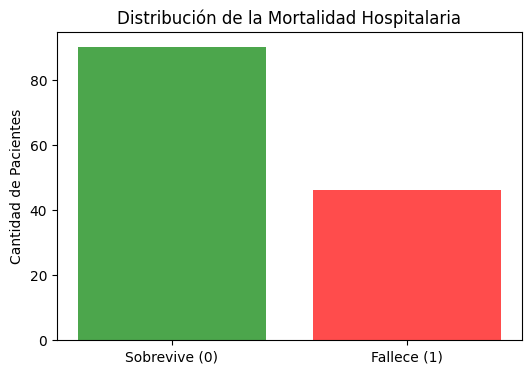

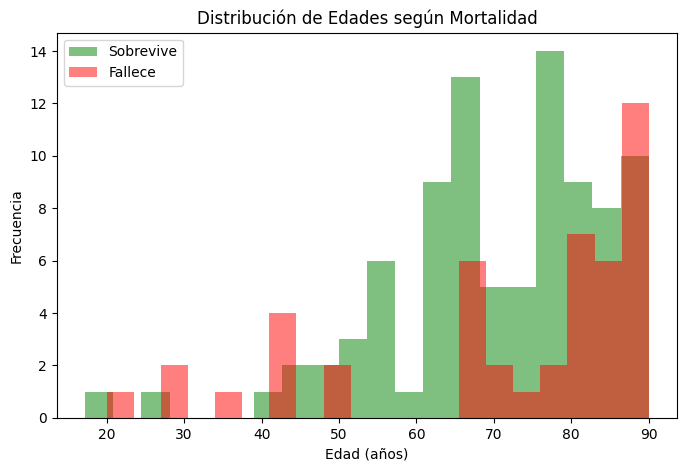

In [97]:
# Distribución de la variable objetivo (Mortalidad)
mortalidad_counts = df_final['hospital_expire_flag'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(['Sobrevive (0)', 'Fallece (1)'], mortalidad_counts.values, color=['green', 'red'], alpha=0.7)
plt.title('Distribución de la Mortalidad Hospitalaria')
plt.ylabel('Cantidad de Pacientes')
plt.show()

# Visualización 2: Relación entre Edad y Mortalidad
plt.figure(figsize=(8,5))
plt.hist(df_final[df_final['hospital_expire_flag']==0]['age'], bins=20, alpha=0.5, label='Sobrevive', color='green')
plt.hist(df_final[df_final['hospital_expire_flag']==1]['age'], bins=20, alpha=0.5, label='Fallece', color='red')
plt.title('Distribución de Edades según Mortalidad')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [98]:
# Convertir a arreglos de numpy
X = df_final[['age', 'gender', 'los']].values
y = df_final['hospital_expire_flag'].values.reshape(-1, 1)

# Semilla para reproducibilidad
np.random.seed(42)

# Mezclar los índices aleatoriamente
indices = np.random.permutation(len(X))

# Calcular el punto de corte para el 75%
split_idx = int(0.75 * len(X))

# Dividir en Entrenamiento (75%) y Prueba (25%)
train_idx, test_idx = indices[:split_idx], indices[split_idx:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Escalado de características (Estandarización: (X - media) / desviacion_estandar)
# Calculamos media y std solo con datos de entrenamiento para evitar fuga de información
media = np.mean(X_train, axis=0)
desviacion = np.std(X_train, axis=0)

X_train_scaled = (X_train - media) / desviacion
X_test_scaled = (X_test - media) / desviacion

print(X_train_scaled)
# Agregar una columna de 1s para el término independiente (sesgo/bias)
X_train_scaled = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_scaled = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

print(f"Dimensiones X_train: {X_train_scaled.shape}, y_train: {y_train.shape}")
print(f"Dimensiones X_test: {X_test_scaled.shape}, y_test: {y_test.shape}")

[[ 1.19521948e-01 -1.01980390e+00 -3.56882554e-01]
 [ 1.24252988e-01 -1.01980390e+00 -2.87491382e-02]
 [-2.04472753e-01 -1.01980390e+00 -1.72165983e-01]
 [-4.04644705e-01  9.80580676e-01 -4.39292091e-01]
 [ 6.56859702e-02 -1.01980390e+00 -5.28085773e-01]
 [ 9.72577481e-01  9.80580676e-01 -6.30012974e-01]
 [ 1.04272739e+00 -1.01980390e+00 -2.25620422e-01]
 [-4.80993910e-01  9.80580676e-01 -2.90645214e-01]
 [ 7.53155088e-01 -1.01980390e+00 -5.66975010e-01]
 [ 6.13834104e-01 -1.01980390e+00 -5.35872386e-01]
 [ 4.85932873e-01 -1.01980390e+00  1.10387261e-01]
 [ 7.58538686e-01 -1.01980390e+00 -3.07416380e-01]
 [-1.74222403e+00 -1.01980390e+00  1.47710582e+00]
 [ 1.15627236e+00  9.80580676e-01 -1.21063597e-01]
 [ 4.18393192e-01  9.80580676e-01 -4.83192225e-01]
 [-2.43669375e-02  9.80580676e-01 -3.62024933e-01]
 [ 1.15627236e+00  9.80580676e-01 -6.28800424e-01]
 [-1.17193214e-01 -1.01980390e+00  1.47935561e+00]
 [-1.28918613e+00  9.80580676e-01 -5.31226715e-01]
 [ 9.74372013e-01  9.80580676e-

In [99]:
# Función Sigmoide
def sigmoid(z):
    # Se usa np.clip para evitar desbordamientos en la exponencial (overflow)
    z = np.clip(z, -250, 250)
    return 1 / (1 + np.exp(-z))

# Función de Costo (Log Loss / Entropía Cruzada Binaria)
def compute_cost(X, y, theta):
    m = len(y)
    h = sigmoid(X.dot(theta))
    # Epsilon para evitar log(0)
    epsilon = 1e-15 
    cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost

# Entrenamiento mediante Descenso de Gradiente
def gradient_descent(X, y, alpha, epochs):
    m, n = X.shape
    # Inicializar pesos (theta) en ceros
    theta = np.zeros((n, 1))
    cost_history = []

    for i in range(epochs):
        # Predicción
        h = sigmoid(X.dot(theta))
        
        # Calcular gradiente
        gradient = (1/m) * X.T.dot(h - y)
        
        # Actualizar pesos
        theta = theta - alpha * gradient
        
        # Guardar costo
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        
        # Imprimir progreso cada 500 iteraciones
        if i % 500 == 0:
            print(f"Iteración {i} | Costo: {cost:.4f}")
            
    return theta, cost_history

Iniciando entrenamiento...
Iteración 0 | Costo: 0.6928
Iteración 500 | Costo: 0.6366
Iteración 1000 | Costo: 0.6315
Iteración 1500 | Costo: 0.6310
Iteración 2000 | Costo: 0.6309
Iteración 2500 | Costo: 0.6309
Iteración 3000 | Costo: 0.6309
Iteración 3500 | Costo: 0.6309
Iteración 4000 | Costo: 0.6309
Iteración 4500 | Costo: 0.6309
Entrenamiento finalizado.



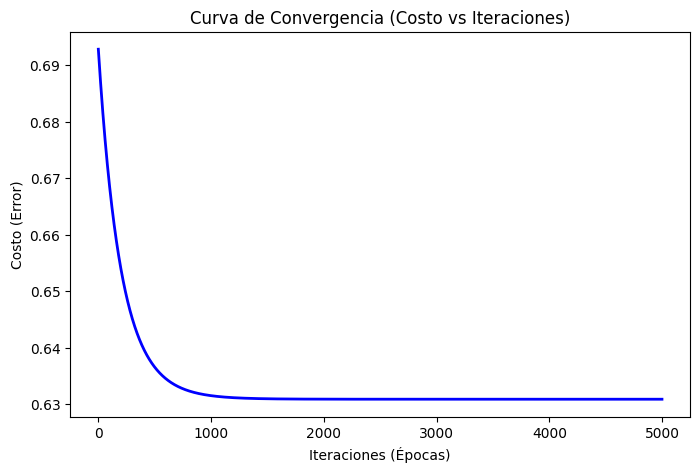

In [100]:
# Hiperparámetros
tasa_aprendizaje = 0.01
epocas = 5000

# Entrenar modelo
print("Iniciando entrenamiento...")
theta_optimo, historial_costo = gradient_descent(X_train_scaled, y_train, tasa_aprendizaje, epocas)
print("Entrenamiento finalizado.\n")

# Visualización de la Convergencia (Disminución del Error)
plt.figure(figsize=(8,5))
plt.plot(range(epocas), historial_costo, color='blue', linewidth=2)
plt.title('Curva de Convergencia (Costo vs Iteraciones)')
plt.xlabel('Iteraciones (Épocas)')
plt.ylabel('Costo (Error)')
plt.show()

In [101]:
# Función para predecir clases (umbral 0.5)
def predict(X, theta, threshold=0.5):
    probabilidades = sigmoid(X.dot(theta))
    return (probabilidades >= threshold).astype(int)

# Predicciones sobre el set de prueba
y_pred = predict(X_test_scaled, theta_optimo)

# Cálculo manual de métricas
verdaderos_positivos = np.sum((y_pred == 1) & (y_test == 1))
verdaderos_negativos = np.sum((y_pred == 0) & (y_test == 0))
falsos_positivos = np.sum((y_pred == 1) & (y_test == 0))
falsos_negativos = np.sum((y_pred == 0) & (y_test == 1))

total_test = len(y_test)
accuracy = (verdaderos_positivos + verdaderos_negativos) / total_test

print("=== Resultados de la Evaluación (Set de Prueba 25%) ===")
print(f"Exactitud (Accuracy): {accuracy * 100:.2f}%")

print("\nMatriz de Confusión:")
print(f"VP: {verdaderos_positivos} | FP: {falsos_positivos}")
print(f"FN: {falsos_negativos} | VN: {verdaderos_negativos}")

=== Resultados de la Evaluación (Set de Prueba 25%) ===
Exactitud (Accuracy): 67.65%

Matriz de Confusión:
VP: 0 | FP: 0
FN: 11 | VN: 23
